<a href="https://colab.research.google.com/github/RachaRamcharan/NLP/blob/main/NLP_4_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

print("Libraries imported: pandas, nltk, re, matplotlib.pyplot, TfidfVectorizer.")

df = pd.read_csv('Tweets.csv')

print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Libraries imported: pandas, nltk, re, matplotlib.pyplot, TfidfVectorizer.
Dataset loaded successfully. Displaying the first 5 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [2]:
nltk.download(['stopwords', 'wordnet', 'omw-1.4'])
print("NLTK data 'stopwords', 'wordnet', and 'omw-1.4' downloaded.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


NLTK data 'stopwords', 'wordnet', and 'omw-1.4' downloaded.


In [3]:
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 4. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 5. Tokenize text
    tokens = nltk.word_tokenize(text)
    # 6. Initialize stopwords and lemmatizer
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    # 7. Remove stopwords and lemmatize
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    # 8. Join words back into a string
    return ' '.join(processed_tokens)

# Apply the function to create a new 'clean_text' column
df['clean_text'] = df['text'].apply(preprocess_text)

print("Text preprocessing complete. Displaying the first 5 rows with the new 'clean_text' column:")
df.head()

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [4]:
nltk.download(['stopwords', 'wordnet', 'omw-1.4', 'punkt'])
print("NLTK data 'stopwords', 'wordnet', 'omw-1.4', and 'punkt' downloaded.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK data 'stopwords', 'wordnet', 'omw-1.4', and 'punkt' downloaded.


**Reasoning**:
The NLTK 'punkt' tokenizer data has been successfully downloaded in the previous step. Now I will re-run the `preprocess_text` function to clean the 'text' column, apply it to create a new 'clean_text' column, and then display the head of the DataFrame to show the results, as the dependency issue for `nltk.word_tokenize` is resolved.



In [5]:
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 4. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 5. Tokenize text
    tokens = nltk.word_tokenize(text)
    # 6. Initialize stopwords and lemmatizer
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    # 7. Remove stopwords and lemmatize
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    # 8. Join words back into a string
    return ' '.join(processed_tokens)

# Apply the function to create a new 'clean_text' column
df['clean_text'] = df['text'].apply(preprocess_text)

print("Text preprocessing complete. Displaying the first 5 rows with the new 'clean_text' column:")
df.head()

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [6]:
nltk.download('punkt_tab')
print("NLTK data 'punkt_tab' downloaded.")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK data 'punkt_tab' downloaded.


In [7]:
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 4. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 5. Tokenize text
    tokens = nltk.word_tokenize(text)
    # 6. Initialize stopwords and lemmatizer
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    # 7. Remove stopwords and lemmatize
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    # 8. Join words back into a string
    return ' '.join(processed_tokens)

# Apply the function to create a new 'clean_text' column
df['clean_text'] = df['text'].apply(preprocess_text)

print("Text preprocessing complete. Displaying the first 5 rows with the new 'clean_text' column:")
df.head()

Text preprocessing complete. Displaying the first 5 rows with the new 'clean_text' column:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,clean_text
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada),virginamerica dhepburn said
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada),virginamerica plus youve added commercial expe...
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada),virginamerica didnt today must mean need take ...
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada),virginamerica really aggressive blast obnoxiou...
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada),virginamerica really big bad thing


In [8]:
df_positive = df[df['airline_sentiment'] == 'positive']
df_negative = df[df['airline_sentiment'] == 'negative']
df_neutral = df[df['airline_sentiment'] == 'neutral']

print("Head of Positive Sentiment DataFrame:")
print(df_positive.head())

print("\nHead of Negative Sentiment DataFrame:")
print(df_negative.head())

print("\nHead of Neutral Sentiment DataFrame:")
print(df_neutral.head())

Head of Positive Sentiment DataFrame:
              tweet_id airline_sentiment  airline_sentiment_confidence  \
1   570301130888122368          positive                        0.3486   
6   570300616901320704          positive                        0.6745   
8   570299953286942721          positive                        0.6559   
9   570295459631263746          positive                        1.0000   
11  570289724453216256          positive                        1.0000   

   negativereason  negativereason_confidence         airline  \
1             NaN                        0.0  Virgin America   
6             NaN                        0.0  Virgin America   
8             NaN                        NaN  Virgin America   
9             NaN                        NaN  Virgin America   
11            NaN                        NaN  Virgin America   

   airline_sentiment_gold          name negativereason_gold  retweet_count  \
1                     NaN      jnardino               

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize three separate TfidfVectorizer objects
vectorizer_positive = TfidfVectorizer()
vectorizer_negative = TfidfVectorizer()
vectorizer_neutral = TfidfVectorizer()

# 2. Fit and transform the 'clean_text' column from df_positive
tfidf_matrix_positive = vectorizer_positive.fit_transform(df_positive['clean_text'])

# 3. Fit and transform the 'clean_text' column from df_negative
tfidf_matrix_negative = vectorizer_negative.fit_transform(df_negative['clean_text'])

# 4. Fit and transform the 'clean_text' column from df_neutral
tfidf_matrix_neutral = vectorizer_neutral.fit_transform(df_neutral['clean_text'])

# 5. Print the shape of each TF-IDF matrix
print(f"Shape of Positive TF-IDF matrix: {tfidf_matrix_positive.shape}")
print(f"Shape of Negative TF-IDF matrix: {tfidf_matrix_negative.shape}")
print(f"Shape of Neutral TF-IDF matrix: {tfidf_matrix_neutral.shape}")

Shape of Positive TF-IDF matrix: (2363, 4086)
Shape of Negative TF-IDF matrix: (9178, 9592)
Shape of Neutral TF-IDF matrix: (3099, 5226)


In [10]:
import pandas as pd
import numpy as np

def get_top_tfidf_words(vectorizer, tfidf_matrix, n=15):
    # Calculate the average TF-IDF score for each word
    avg_tfidf_scores = tfidf_matrix.mean(axis=0).A1

    # Get feature names (words) from the vectorizer
    feature_names = vectorizer.get_feature_names_out()

    # Create a DataFrame to pair words with their average TF-IDF scores
    tfidf_scores_df = pd.DataFrame({'word': feature_names, 'avg_tfidf': avg_tfidf_scores})

    # Sort by average TF-IDF scores in descending order and select the top n words
    top_words_df = tfidf_scores_df.sort_values(by='avg_tfidf', ascending=False).head(n)

    return top_words_df

# Apply the function for each sentiment category
top_positive_words = get_top_tfidf_words(vectorizer_positive, tfidf_matrix_positive)
top_negative_words = get_top_tfidf_words(vectorizer_negative, tfidf_matrix_negative)
top_neutral_words = get_top_tfidf_words(vectorizer_neutral, tfidf_matrix_neutral)

# Print the top words for each sentiment
print("Top 15 words for Positive Sentiment:")
print(top_positive_words)

print("\nTop 15 words for Negative Sentiment:")
print(top_negative_words)

print("\nTop 15 words for Neutral Sentiment:")
print(top_neutral_words)

Top 15 words for Positive Sentiment:
               word  avg_tfidf
3630         thanks   0.057440
3624          thank   0.054295
2048        jetblue   0.049088
3825         united   0.045739
3399   southwestair   0.043600
138     americanair   0.036549
3849      usairways   0.030873
1281         flight   0.029150
1488          great   0.023400
3892  virginamerica   0.017015
2504           much   0.015049
3260        service   0.014749
2287           love   0.013929
1512            guy   0.013707
288         awesome   0.013287

Top 15 words for Negative Sentiment:
              word  avg_tfidf
3008        flight   0.042855
8879        united   0.038287
9000     usairways   0.034877
299    americanair   0.031730
7893  southwestair   0.022253
3801          hour   0.021790
4714       jetblue   0.020565
3339           get   0.019277
1154     cancelled   0.018278
1878      customer   0.016048
7553       service   0.016035
8508          time   0.014966
3723          hold   0.014794
3651     

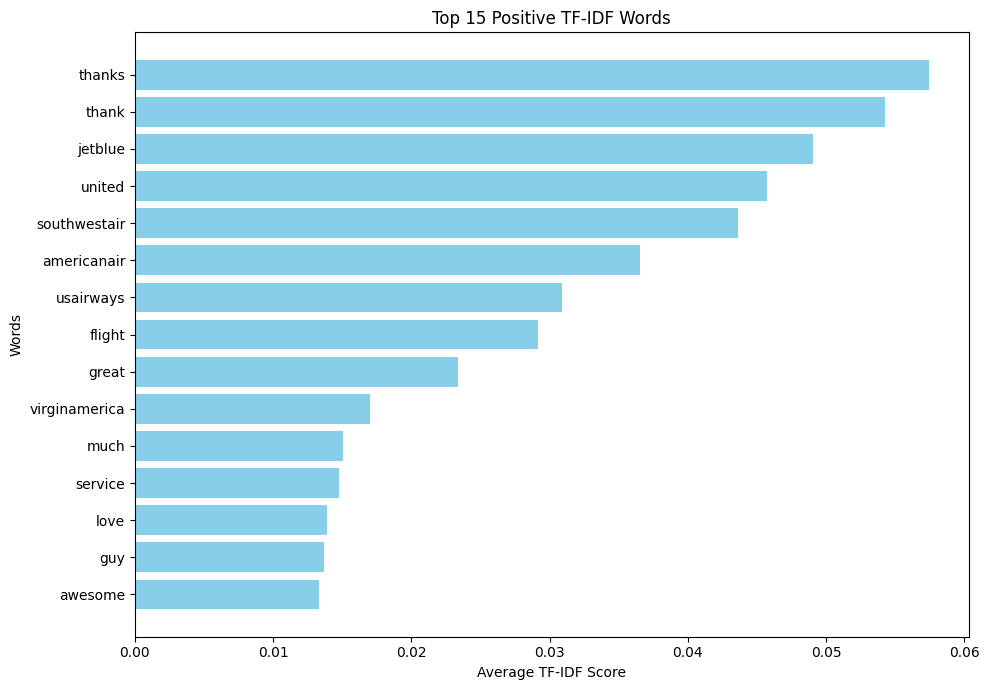

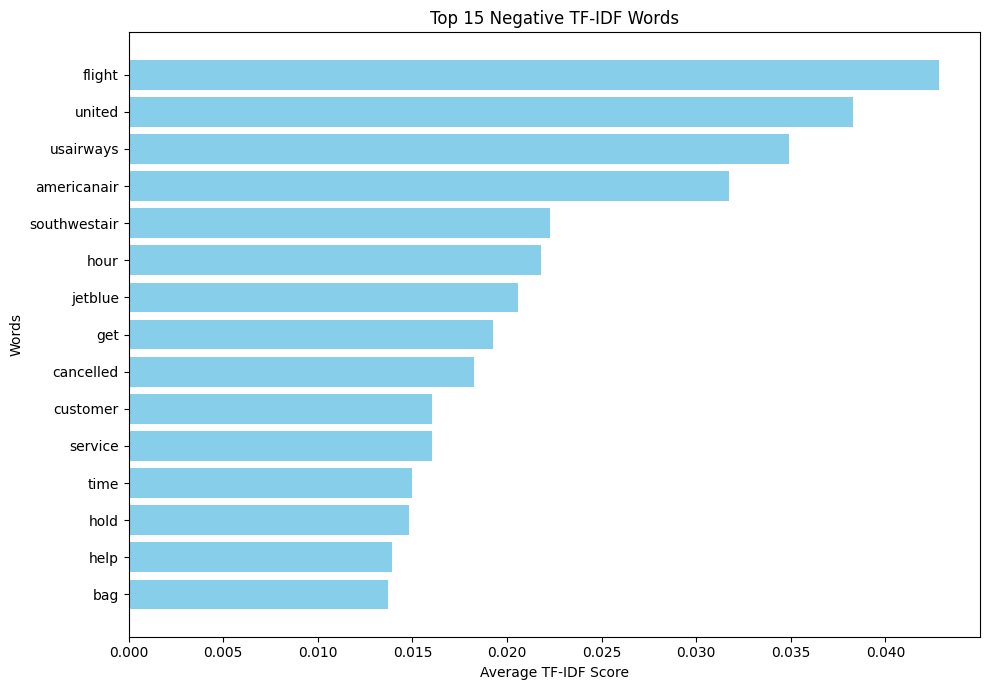

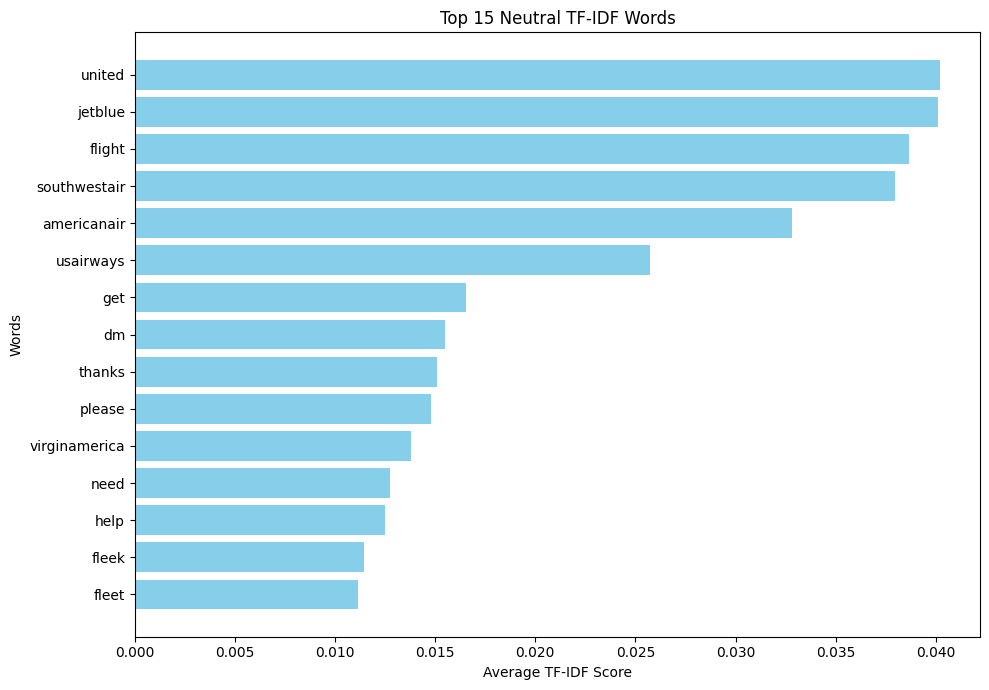

In [11]:
import matplotlib.pyplot as plt

def plot_top_words(words_df, sentiment_label):
    plt.figure(figsize=(10, 7))
    plt.barh(words_df['word'], words_df['avg_tfidf'], color='skyblue')
    plt.xlabel('Average TF-IDF Score')
    plt.ylabel('Words')
    plt.title(f'Top 15 {sentiment_label} TF-IDF Words')
    plt.gca().invert_yaxis() # Display top word at the top
    plt.tight_layout()
    plt.show()

# Plot for Positive Sentiment
plot_top_words(top_positive_words, 'Positive')

# Plot for Negative Sentiment
plot_top_words(top_negative_words, 'Negative')

# Plot for Neutral Sentiment
plot_top_words(top_neutral_words, 'Neutral')
